In [1]:
## Slides examples:

## Anomaly detection --------------------------------------------------
from sklearn.ensemble import IsolationForest
import pandas as pd

# # Exemple de données:
data = pd.DataFrame({
    'Feature1': [1, 2, 2, 3, 4, 5, 100],
    'Feature2': [1, 1, 2, 2, 3, 4, 100]
})

# # Initialisation:
iso_forest = IsolationForest(contamination=0.1, random_state=42)

# # Ajustement sur les données:
iso_forest.fit(data)

# # Prédictions: -1 pour les anomalies, 1 pour les points valides
predictions = iso_forest.predict(data)

# # Score d'anomalie:
anomaly_score = iso_forest.decision_function(data)

# # Ajout du score au df:
data['anomaly'] = predictions
data['anomaly_score'] = anomaly_score

print(data)


   Feature1  Feature2  anomaly  anomaly_score
0         1         1        1       0.179492
1         2         1        1       0.222783
2         2         2        1       0.229702
3         3         2        1       0.228740
4         4         3        1       0.188927
5         5         4        1       0.110478
6       100       100       -1      -0.165716


Erreur quadratique moyenne (MSE): 4.48
Score R²: 0.91


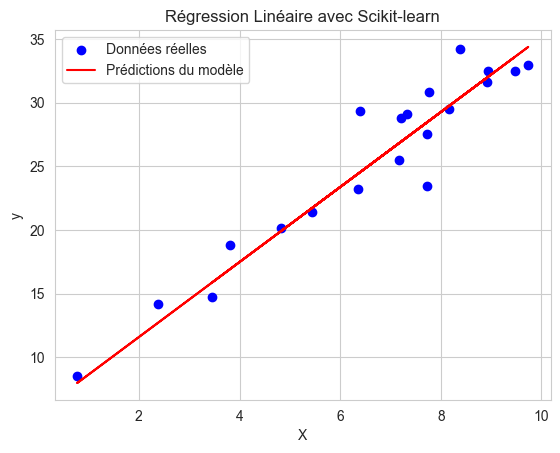

In [2]:
# # Regression Linéaire:
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# # 1. Génération de données synthétiques
X = np.random.rand(100, 1) * 10  # Caractéristiques
y = 3 * X.flatten() + 5 + np.random.randn(100) * 2  # Cible avec un peu de bruit

# # 2. Division des données en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # 3. Création et entraînement du modèle de régression linéaire
model = LinearRegression()
model.fit(X_train, y_train)

# # 4. Prédictions
y_pred = model.predict(X_test)

# # 5. Évaluation du modèle
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erreur quadratique moyenne (MSE): {mse:.2f}")
print(f"Score R²: {r2:.2f}")

# # 6. Visualisation des résultats
plt.scatter(X_test, y_test, color='blue', label="Données réelles")
plt.plot(X_test, y_pred, color='red', label="Prédictions du modèle")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Régression Linéaire avec Scikit-learn")
plt.legend()
plt.show()


Précision (Accuracy) : 0.97

Matrice de confusion :
[[22  1]
 [ 0 17]]

Rapport de classification :
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        23
           1       0.94      1.00      0.97        17

    accuracy                           0.97        40
   macro avg       0.97      0.98      0.97        40
weighted avg       0.98      0.97      0.98        40



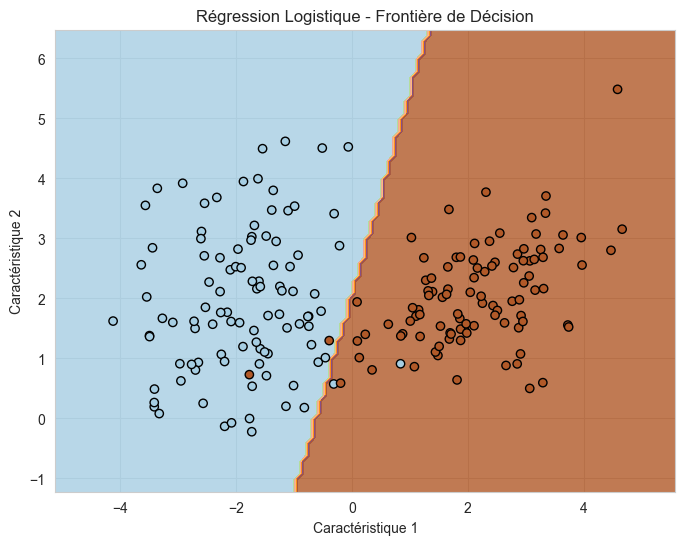

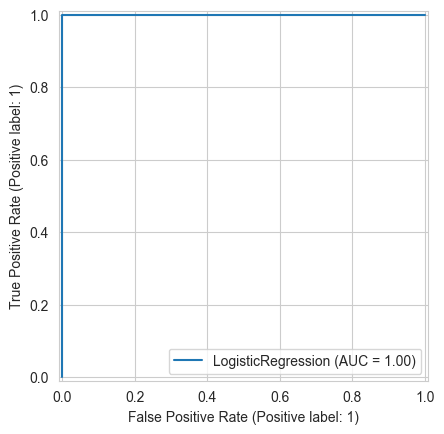

In [3]:
# # Régression logistique:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, RocCurveDisplay

# # 1. Génération de données synthétiques
X, y = make_classification(
    n_samples=200,  # Nombre d'exemples
    n_features=2,   # Nombre de caractéristiques
    n_informative=2, # Caractéristiques pertinentes
    n_redundant=0,  # Aucune caractéristique redondante
    n_clusters_per_class=1,  # Un cluster par classe
    class_sep=2.0,  # Séparation entre les classes
    random_state=42
)

# # 2. Division des données en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



# # 3. Création et entraînement du modèle de régression logistique
model = LogisticRegression()
model.fit(X_train, y_train)

# # 4. Prédictions
y_pred = model.predict(X_test)

# # 5. Évaluation du modèle
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Précision (Accuracy) : {accuracy:.2f}")
print("\nMatrice de confusion :")
print(conf_matrix)
print("\nRapport de classification :")
print(classification_report(y_test, y_pred))

# # 6. Visualisation des données et de la frontière de décision
plt.figure(figsize=(8, 6))
# # Meshgrid pour la visualisation
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# # Contour de la frontière de décision
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)

# # Points de données
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.Paired)
plt.title("Régression Logistique - Frontière de Décision")
plt.xlabel("Caractéristique 1")
plt.ylabel("Caractéristique 2")
plt.show()

# # 7. Courbe ROC
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()


In [4]:
## Standardisation
import numpy as np
from sklearn.preprocessing import StandardScaler

# # Exemple de données:
X = np.array([[1, 2], [3, 4], [5, 6]])

# # Création d'un scaler:
scaler = StandardScaler()

# # Étape 1: Apprentissage
scaler.fit(X)
print(f'Moyenne: {scaler.mean_}')  # notez le ".mean_"
print(f'Écart type: {scaler.scale_}')  # notez le ".scale_"

# # Étape 2: Transformation
X_scaled = scaler.transform(X)
print(f'Données normalisées: {X_scaled}')

# # Étape combinée: apprentissage + transformation:
X_scaled_combined = scaler.fit_transform(X)
print(f'Données normalisées (fit_transform): {X_scaled_combined}')

Moyenne: [3. 4.]
Écart type: [1.63299316 1.63299316]
Données normalisées: [[-1.22474487 -1.22474487]
 [ 0.          0.        ]
 [ 1.22474487  1.22474487]]
Données normalisées (fit_transform): [[-1.22474487 -1.22474487]
 [ 0.          0.        ]
 [ 1.22474487  1.22474487]]


In [6]:
# # Normalisation:
from sklearn.preprocessing import Normalizer
import numpy as np

# # Exemple de données:
X = np.array([[1, 2], [3, 4], [5, 6]])

# # Instanciation du normaliseur:
normalizer = Normalizer(norm='l2')

# # Calibration sur la donnée:
normalizer.fit(X)

# # Application à la donnée:
X_normalized = normalizer.transform(X)
print(f'X_normalized:\n{X_normalized}')


X_normalized:
[[0.4472136  0.89442719]
 [0.6        0.8       ]
 [0.6401844  0.76822128]]


In [9]:
# # OneHotEncoder:
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd

# # Exemple de données catégorielles:
data = pd.DataFrame({
    'couleur': ['rouge', 'bleu', 'vert', 'rouge', 'bleu'],
    'taille': ['petit', 'grand', 'moyen', 'petit', 'moyen']
})

# # Instanciation du OrdinalEncoder:
ordinal_encoder = OrdinalEncoder()

# # Transformation:
encoded_data = ordinal_encoder.fit_transform(data)

print(f'Données encodées:\n{encoded_data}')
print('Mapping des catégories:')
for i, cat in enumerate(ordinal_encoder.categories_):
    print(f'\tFeature "{data.columns[i]}": {cat}')

Données encodées:
[[1. 2.]
 [0. 0.]
 [2. 1.]
 [1. 2.]
 [0. 1.]]
Mapping des catégories:
	Feature "couleur": ['bleu' 'rouge' 'vert']
	Feature "taille": ['grand' 'moyen' 'petit']


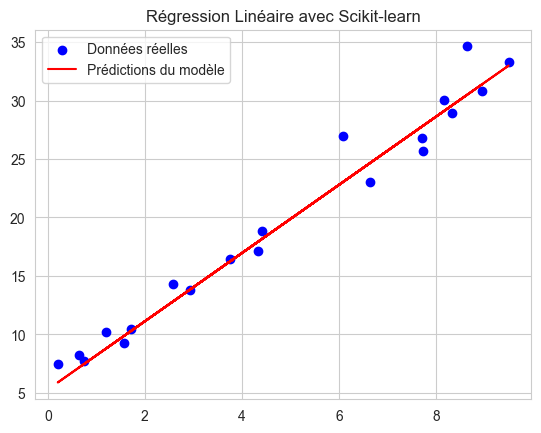

In [10]:
# # Séparation test / validation:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# # 1. Génération de données synthétiques
np.random.seed(42)  # Pour reproductibilité
X = np.random.rand(100, 1) * 10  # Caractéristiques
y = 3 * X.flatten() + 5 + np.random.randn(100) * 2  # Cible avec un peu de bruit

# # 2. Division des données en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # 3. Création et entraînement du modèle de régression linéaire
model = LinearRegression()
model.fit(X_train, y_train)

# # 4. Prédictions
y_pred = model.predict(X_test)

# # 5. Visualisation des résultats
plt.scatter(X_test, y_test, color='blue', label="Données réelles")
plt.plot(X_test, y_pred, color='red', label="Prédictions du modèle")
plt.title("Régression Linéaire avec Scikit-learn")
plt.legend()
plt.show()


Erreur quadratique moyenne (MSE): 2.61
Score R²: 0.97


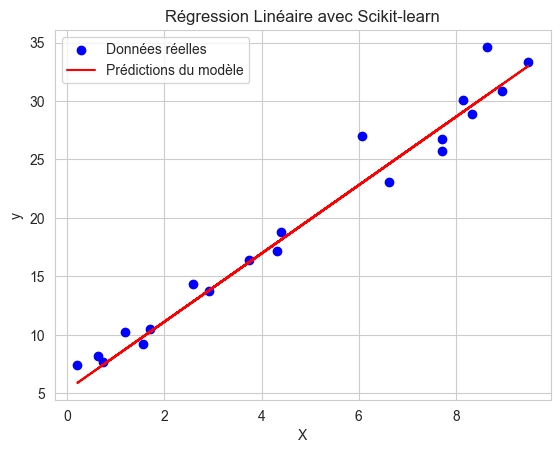

In [11]:
# # Qualité du modèle: régression linéaire:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Génération de données synthétiques
np.random.seed(42)  # Pour reproductibilité
X = np.random.rand(100, 1) * 10  # Caractéristiques
y = 3 * X.flatten() + 5 + np.random.randn(100) * 2  # Cible avec un peu de bruit

# 2. Division des données en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Création et entraînement du modèle de régression linéaire
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Prédictions
y_pred = model.predict(X_test)

# 5. Évaluation du modèle
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erreur quadratique moyenne (MSE): {mse:.2f}")
print(f"Score R²: {r2:.2f}")

# 6. Visualisation des résultats
plt.scatter(X_test, y_test, color='blue', label="Données réelles")
plt.plot(X_test, y_pred, color='red', label="Prédictions du modèle")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Régression Linéaire avec Scikit-learn")
plt.legend()
plt.show()


In [13]:
# # Évaluer la qualité d'un modèle: régression logistique:

from sklearn.metrics import confusion_matrix, classification_report

# # Valeurs réelles et prédictions du modèle:
y_true = [1, 0, 1, 1, 0, 0, 1, 0, 1, 0]  # 1 = Spam, 0 = Non Spam
y_pred = [1, 0, 0, 1, 1, 0, 1, 0, 0, 1]

# # Génération de la matrice de confusion:
cm = confusion_matrix(y_true, y_pred)

print(f'Matrice de confusion:\n{cm}')

# # Rapport de classification (précision, rappel, F1-score)
print(f"\nRapport de classification :\n{classification_report(y_true, y_pred)}")



Matrice de confusion:
[[3 2]
 [2 3]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.60      0.60      0.60         5
           1       0.60      0.60      0.60         5

    accuracy                           0.60        10
   macro avg       0.60      0.60      0.60        10
weighted avg       0.60      0.60      0.60        10

